In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"auroraihrish354","key":"509b4ef98f8d26763043389554dbb1cf"}'}

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d sshikamaru/fruit-recognition

Dataset URL: https://www.kaggle.com/datasets/sshikamaru/fruit-recognition
License(s): other
100% 102M/102M [00:01<00:00, 82.1MB/s] 



In [ ]:
import zipfile

zip_ref = zipfile.ZipFile(
    "fruit-recognition.zip",
    'r'
)

zip_ref.extractall("dataset")

zip_ref.close()

print("Extract selesai")

Extract selesai


In [ ]:
import os

os.listdir("dataset")

['sampleSubmission.csv', 'test', 'train']

In [ ]:
import os

os.listdir("dataset/train/train")

['Plum',
 'Limes',
 'Cactus fruit',
 'Cherry',
 'Papaya',
 'Apple Granny Smith',
 'Apricot',
 'Pepper Green',
 'Watermelon',
 'Blueberry',
 'Onion White',
 'Potato Red',
 'Peach',
 'Pineapple',
 'Kiwi',
 'Cucumber Ripe',
 'Banana',
 'Cantaloupe',
 'Orange',
 'Clementine',
 'Apple Braeburn',
 'Lemon',
 'Tomato',
 'Strawberry',
 'Corn',
 'Pomegranate',
 'Passion Fruit',
 'Avocado',
 'Raspberry',
 'Grape Blue',
 'Mango',
 'Pear',
 'Pepper Red']

Label: ['Plum', 'Limes', 'Cactus fruit', 'Cherry', 'Papaya', 'Apple Granny Smith', 'Apricot', 'Pepper Green', 'Watermelon', 'Blueberry', 'Onion White', 'Potato Red', 'Peach', 'Pineapple', 'Kiwi', 'Cucumber Ripe', 'Banana', 'Cantaloupe', 'Orange', 'Clementine', 'Apple Braeburn', 'Lemon', 'Tomato', 'Strawberry', 'Corn', 'Pomegranate', 'Passion Fruit', 'Avocado', 'Raspberry', 'Grape Blue', 'Mango', 'Pear', 'Pepper Red']
Total data: 16854
Jumlah data training: 13483
Jumlah data testing: 3371

AKURASI:
0.9994067042420647

CONFUSION MATRIX:
[[ 178    0    0]
 [   2 3023    0]
 [   0    0  168]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Busuk       0.99      1.00      0.99       178
      Matang       1.00      1.00      1.00      3025
      Mentah       1.00      1.00      1.00       168

    accuracy                           1.00      3371
   macro avg       1.00      1.00      1.00      3371
weighted avg       1.00      1.00      1.00      3371


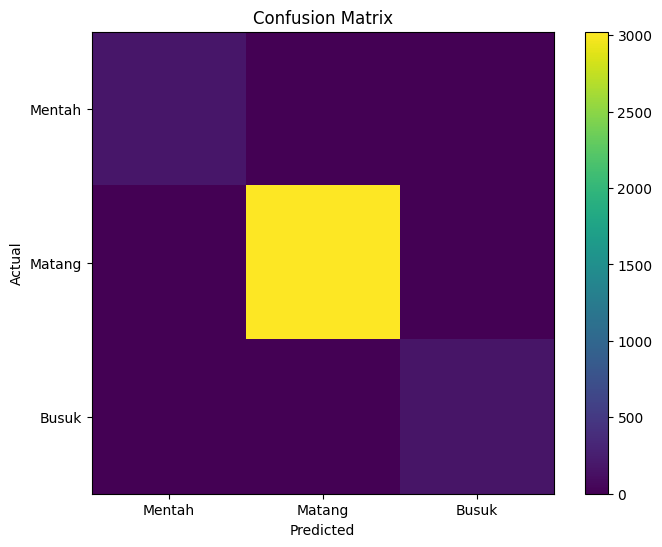

In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import os
import cv2
import numpy as np

from skimage.feature import graycomatrix, graycoprops

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import joblib

# =========================================================
# PATH DATASET
# =========================================================

train_path = "dataset/train/train"

labels = os.listdir(train_path)

print("Label:", labels)


# =========================================================
# FUNGSI EKSTRAKSI FITUR
# =========================================================
def prediksi_gambar(path):

    fitur = extract_features(path)

    if fitur is None:
        print("Gambar tidak terbaca")
        return

    hasil = model.predict([fitur])

    print("Hasil prediksi:", hasil[0])
def extract_features(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return None

    # Resize
    img = cv2.resize(img, (300, 300))

    # RGB -> HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian Filter
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # SEGMENTASI OTSU
    _, thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # ======================
    # FITUR WARNA (HSV)
    # ======================

    h = np.mean(hsv[:,:,0])
    s = np.mean(hsv[:,:,1])
    v = np.mean(hsv[:,:,2])

    # ======================
    # FITUR TEKSTUR (GLCM)
    # ======================

    glcm = graycomatrix(
        blur,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

    return [
        h,
        s,
        v,
        contrast,
        energy,
        homogeneity
    ]

# =========================================================
# FUNGSI KATEGORI KEMATANGAN
# =========================================================

def kategori_kematangan(label):

    matang = [
        "Apple Braeburn",
        "Apple Granny Smith",
        "Apricot",
        "Avocado",
        "Banana",
        "Blueberry",
        "Cherry",
        "Grape Blue",
        "Kiwi",
        "Lemon",
        "Limes",
        "Mango",
        "Orange",
        "Papaya",
        "Peach",
        "Pear",
        "Pineapple",
        "Plum",
        "Pomegranate",
        "Raspberry",
        "Strawberry",
        "Tomato",
        "Watermelon"
    ]

    mentah = [
        "Corn",
        "Cucumber Ripe"
    ]

    busuk = [
        "Onion White",
        "Potato Red"
    ]

    if label in matang:
        return "Matang"

    elif label in mentah:
        return "Mentah"

    elif label in busuk:
        return "Busuk"

    else:
        return "Matang"
# =========================================================
# LOAD DATASET
# =========================================================

X = []
y = []

for label in labels:

    folder = os.path.join(train_path, label)

    for file in os.listdir(folder):

        path = os.path.join(folder, file)

        fitur = extract_features(path)

        if fitur is not None:

            X.append(fitur)

            y.append(kategori_kematangan(label))


print("Total data:", len(X))


# =========================================================
# SPLIT TRAIN DAN TEST
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))


# =========================================================
# TRAIN MODEL KNN
# =========================================================

model = KNeighborsClassifier(
    n_neighbors=3
)

model.fit(
    X_train,
    y_train
)

joblib.dump(model, "model_knn_kematangan.pkl")
# =========================================================
# PREDIKSI
# =========================================================

y_pred = model.predict(
    X_test
)


# =========================================================
# EVALUASI
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAKURASI:")
print(accuracy)


cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nCONFUSION MATRIX:")
print(cm)


print("\nCLASSIFICATION REPORT:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# =========================================================
# VISUALISASI CONFUSION MATRIX
# =========================================================

labels_cm = ["Mentah", "Matang", "Busuk"]

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(range(len(labels_cm)), labels_cm)
plt.yticks(range(len(labels_cm)), labels_cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()